       η |    QBER=0% |    QBER=2% |    QBER=5%
--------------------------------------------------
 0.0500 |   0.024998 |   0.017926 |   0.010678
 0.1000 |   0.049998 |   0.035854 |   0.021358
 0.1500 |   0.074998 |   0.053782 |   0.032038
 0.2000 |   0.099998 |   0.071710 |   0.042719
 0.2500 |   0.124998 |   0.089638 |   0.053399
 0.3000 |   0.149998 |   0.107566 |   0.064079
 0.3500 |   0.174998 |   0.125494 |   0.074759
 0.4000 |   0.199998 |   0.143422 |   0.085439
 0.4500 |   0.224998 |   0.161350 |   0.096119
 0.5000 |   0.249998 |   0.179278 |   0.106799
 0.5500 |   0.274998 |   0.197206 |   0.117480
 0.6000 |   0.299998 |   0.215134 |   0.128160
 0.6500 |   0.324998 |   0.233062 |   0.138840
 0.7000 |   0.349998 |   0.250990 |   0.149520
 0.7500 |   0.374998 |   0.268918 |   0.160200
 0.8000 |   0.399998 |   0.286846 |   0.170880
 0.8500 |   0.424998 |   0.304773 |   0.181561
 0.9000 |   0.449998 |   0.322701 |   0.192241
 0.9500 |   0.474998 |   0.340629 |   0.202921
 1.0000 

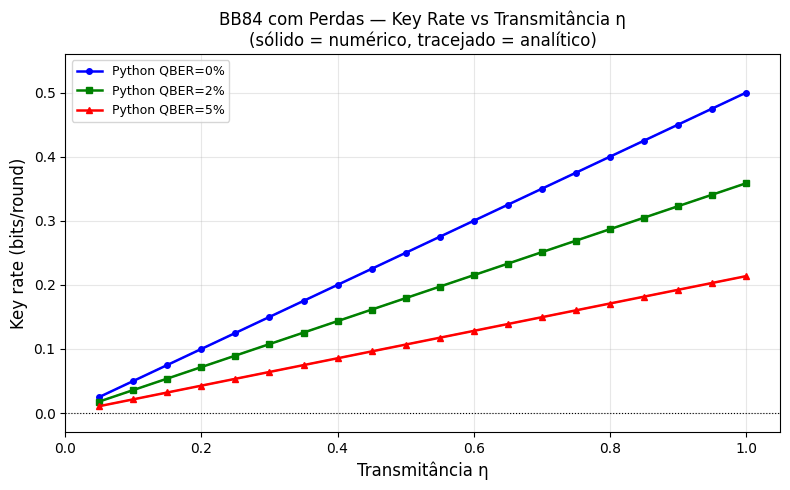


→ benchmark_loss_vs_eta.csv e benchmark_loss_vs_eta.png exportados


In [1]:
"""
Benchmark: key rate vs transmitância η.
Estilo idêntico ao BB84-Simples-Benchmark.ipynb.
Produz: benchmark_loss_vs_eta.csv  +  benchmark_loss_vs_eta.png
"""

import sys, numpy as np, csv
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")

import matplotlib.pyplot as plt
from openqkd.presets.bb84_loss_preset import BasicBB84LossPreset
from openqkd.optimizer.main_iteration  import MainIteration


def h(p):
    if p <= 0 or p >= 1: return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def analytic_loss(eta, qber, pz=0.5):
    """Shor-Preskill com fator de perda: r = η × sift × (1 − 2h(e))"""
    sift = pz**2 + (1 - pz)**2
    return max(0.0, eta * sift * (1 - 2 * h(qber)))


SCENARIOS = {"QBER=0%": 0.00, "QBER=2%": 0.02, "QBER=5%": 0.05}
ETA_RANGE = np.linspace(0.05, 1.0, 20)
PZ = 0.5

# ── Cabeçalho da tabela ────────────────────────────────────────────────────
col = " | ".join(f"{lbl:>10}" for lbl in SCENARIOS)
print(f"{'η':>8} | {col}")
print("-" * (8 + 3 + 13 * len(SCENARIOS)))

rows = []
results = {lbl: [] for lbl in SCENARIOS}

for eta in ETA_RANGE:
    row = {"eta": round(float(eta), 6)}
    line_vals = []
    for label, qber in SCENARIOS.items():
        depol = 2.0 * qber
        r = MainIteration(BasicBB84LossPreset(depolarization=depol, eta=eta, pz=PZ))
        kr = max(0.0, r["key_rate"])
        row[label] = round(kr, 8)
        results[label].append(kr)
        line_vals.append(f"{kr:>10.6f}")
    rows.append(row)
    print(f" {eta:.4f} | {' | '.join(line_vals)}")

# ── CSV ────────────────────────────────────────────────────────────────────
with open("benchmark_loss_vs_eta.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=rows[0].keys())
    w.writeheader(); w.writerows(rows)

# ── Plot ───────────────────────────────────────────────────────────────────
styles = ["b-o", "g-s", "r-^"]
fig, ax = plt.subplots(figsize=(8, 5))

for (label, qber), style in zip(SCENARIOS.items(), styles):
    krs = results[label]
    an  = [analytic_loss(e, qber, PZ) for e in ETA_RANGE]
    ax.plot(ETA_RANGE, krs, style, ms=4, lw=1.8, label=f"Python {label}")
    ax.plot(ETA_RANGE, an,  "--",  lw=1.2, color=style[0], alpha=0.5)

ax.axhline(0, color="k", ls=":", lw=0.8)
ax.set_xlabel("Transmitância η", fontsize=12)
ax.set_ylabel("Key rate (bits/round)", fontsize=12)
ax.set_title(
    "BB84 com Perdas — Key Rate vs Transmitância η\n"
    "(sólido = numérico, tracejado = analítico)",
    fontsize=12
)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xlim(0.0, 1.05); ax.set_ylim(-0.03, 0.56)
plt.tight_layout()
plt.savefig("benchmark_loss_vs_eta.png", dpi=150)
plt.show()

print("\n→ benchmark_loss_vs_eta.csv e benchmark_loss_vs_eta.png exportados")
